<a href="https://colab.research.google.com/github/molecools/molecular-docking/blob/main/Julia_Practice_Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Install Julia
!wget -q 'https://julialang-s3.julialang.org/bin/linux/x64/1.9/julia-1.9.3-linux-x86_64.tar.gz'
import time
time.sleep(5) # Add a short delay
!tar -xzf julia-1.9.3-linux-x86_64.tar.gz
!sudo mv julia-1.9.3 /opt/julia
!sudo ln -s /opt/julia/bin/julia /usr/local/bin/julia

# Install IJulia kernel
!julia -e 'using Pkg; Pkg.add("IJulia")'
!julia -e 'using IJulia; IJulia.installkernel("Julia")'

LoadError: UndefVarError: `wget` not defined

In [5]:
# This should show Julia version
println("Julia version: ", VERSION)
println("You're now running Julia!")

Julia version: 1.10.9
You're now running Julia!


In [6]:
# Install required packages
using Pkg
Pkg.add(["DataFrames", "CSV", "HTTP", "StatsPlots", "Statistics", "MLJ", "MLJDecisionTreeInterface"])

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


In [7]:
using DataFrames
using CSV
using HTTP
using StatsPlots
using Statistics
using MLJ
using MLJDecisionTreeInterface

In [8]:
# Download the Iris dataset directly from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
response = HTTP.get(url)

# Save to a temporary file
open("iris.csv", "w") do file
    write(file, String(response.body))
end

# Define column names (the dataset doesn't have headers)
column_names = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]

# Load the dataset
iris_df = CSV.read("iris.csv", DataFrame, header=false)
rename!(iris_df, column_names)

# Display first few rows
first(iris_df, 5)

Row,sepal_length,sepal_width,petal_length,petal_width,species
,Float64,Float64,Float64,Float64,String15
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
# Check the structure of the dataset
println("Dataset shape: ", size(iris_df))
println("\nColumn names: ", names(iris_df))
println("\nData types:")
for col in names(iris_df)
    println("$col: ", eltype(iris_df[!, col]))
end

Dataset shape: (150, 5)

Column names: ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]

Data types:
sepal_length: Float64
sepal_width: Float64
petal_length: Float64
petal_width: Float64
species: String15


In [10]:
# Basic statistics
describe(iris_df)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,DataType
1,sepal_length,5.84333,4.3,5.8,7.9,0,Float64
2,sepal_width,3.054,2.0,3.0,4.4,0,Float64
3,petal_length,3.75867,1.0,4.35,6.9,0,Float64
4,petal_width,1.19867,0.1,1.3,2.5,0,Float64
5,species,,Iris-setosa,,Iris-virginica,0,String15


In [11]:
# Check for missing values
println("Missing values per column:")
for col in names(iris_df)
    missing_count = sum(ismissing.(iris_df[!, col]))
    println("$col: $missing_count")
end

Missing values per column:
sepal_length: 0
sepal_width: 0
petal_length: 0
petal_width: 0
species: 0


In [12]:
# Check unique species
println("Unique species: ", unique(iris_df.species))
println("Species counts:")
combine(groupby(iris_df, :species), nrow => :count)

Unique species: String15["Iris-setosa", "Iris-versicolor", "Iris-virginica"]
Species counts:


Row,species,count
,String15,Int64
1,Iris-setosa,50
2,Iris-versicolor,50
3,Iris-virginica,50


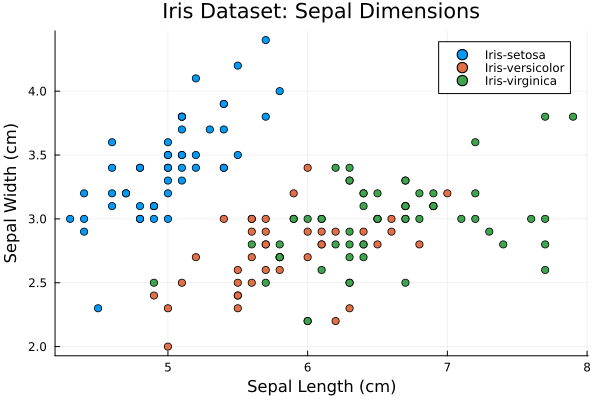

In [13]:
# Create scatter plots
gr() # Use GR backend for plots

# Scatter plot: Sepal Length vs Sepal Width
scatter(iris_df.sepal_length, iris_df.sepal_width,
        group=iris_df.species,
        xlabel="Sepal Length (cm)",
        ylabel="Sepal Width (cm)",
        title="Iris Dataset: Sepal Dimensions",
        legend=:topright)

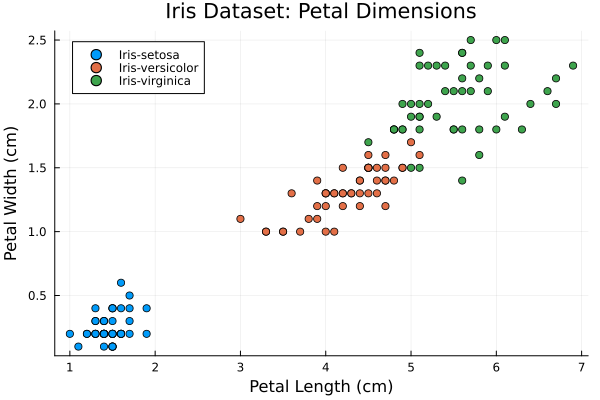

In [14]:
# Scatter plot: Petal Length vs Petal Width
scatter(iris_df.petal_length, iris_df.petal_width,
        group=iris_df.species,
        xlabel="Petal Length (cm)",
        ylabel="Petal Width (cm)",
        title="Iris Dataset: Petal Dimensions",
        legend=:topleft)

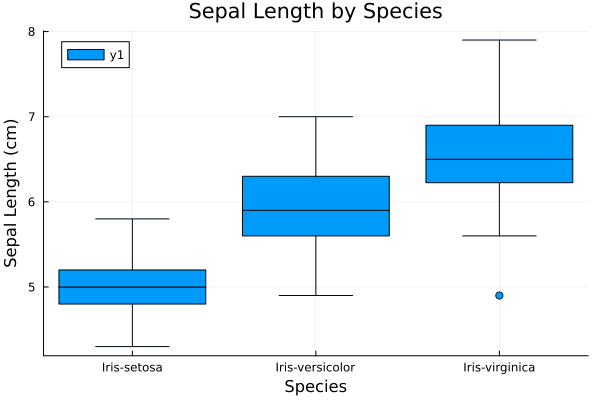

In [15]:
# Box plots for each feature
using StatsPlots
boxplot(iris_df.species, iris_df.sepal_length,
        xlabel="Species", ylabel="Sepal Length (cm)",
        title="Sepal Length by Species")

In [16]:
# Calculate mean and standard deviation for each species
stats_by_species = combine(groupby(iris_df, :species),
    :sepal_length => mean => :mean_sepal_length,
    :sepal_length => std => :std_sepal_length,
    :sepal_width => mean => :mean_sepal_width,
    :sepal_width => std => :std_sepal_width,
    :petal_length => mean => :mean_petal_length,
    :petal_length => std => :std_petal_length,
    :petal_width => mean => :mean_petal_width,
    :petal_width => std => :std_petal_width
)

stats_by_species

Row,species,mean_sepal_length,std_sepal_length,mean_sepal_width,std_sepal_width,mean_petal_length,std_petal_length,mean_petal_width,std_petal_width
,String15,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,Iris-setosa,5.006,0.35249,3.418,0.381024,1.464,0.173511,0.244,0.10721
2,Iris-versicolor,5.936,0.516171,2.77,0.313798,4.26,0.469911,1.326,0.197753
3,Iris-virginica,6.588,0.63588,2.974,0.322497,5.552,0.551895,2.026,0.27465


In [17]:
# Correlation matrix
using LinearAlgebra
numeric_cols = [:sepal_length, :sepal_width, :petal_length, :petal_width]
correlation_matrix = cor(Matrix(iris_df[!, numeric_cols]))

# Create correlation DataFrame for better display
correlation_df = DataFrame(correlation_matrix, numeric_cols)
insertcols!(correlation_df, 1, :Variable => numeric_cols)
correlation_df

Row,Variable,sepal_length,sepal_width,petal_length,petal_width
,Symbol,Float64,Float64,Float64,Float64
1,sepal_length,1.0,-0.109369,0.871754,0.817954
2,sepal_width,-0.109369,1.0,-0.420516,-0.356544
3,petal_length,0.871754,-0.420516,1.0,0.962757
4,petal_width,0.817954,-0.356544,0.962757,1.0


In [20]:
# Add and import Random package
using Pkg
Pkg.add("Random")
using Random

   Resolving package versions...
    Updating `~/.julia/environments/v1.10/Project.toml`
  [9a3f8284] + Random
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


In [23]:
# Prepare data for machine learning
X = select(iris_df, [:sepal_length, :sepal_width, :petal_length, :petal_width])
y = iris_df.species

# Load a decision tree classifier
Tree = @load DecisionTreeClassifier pkg=DecisionTree

# Create the model
tree_model = Tree()

# Split data into training and testing sets (80-20 split)
# Method 1: Using Random.shuffle and manual split
Random.seed!(42)  # For reproducible results
n_total = nrow(iris_df)
n_train = Int(0.8 * n_total)

# Shuffle indices
shuffled_indices = shuffle(1:n_total)
train_indices = shuffled_indices[1:n_train]
test_indices = shuffled_indices[(n_train+1):end]

# Alternative Method 2: Using StatsBase.sample
# train_indices = sample(1:n_total, n_train, replace=false)
# test_indices = setdiff(1:n_total, train_indices)

X_train = X[train_indices, :]
y_train = y[train_indices]
X_test = X[test_indices, :]
y_test = y[test_indices]

# Convert target variable to categorical type for MLJ
y_train = categorical(y_train)
y_test = categorical(y_test)


println("Training set size: ", length(y_train))
println("Test set size: ", length(y_test))

import MLJDecisionTreeInterface ✔
Training set size: 

[ Info: For silent loading, specify `verbosity=0`. 


120
Test set size: 30


In [24]:
# Train the model
mach = machine(tree_model, X_train, y_train)
fit!(mach)

# Make predictions
predictions = predict_mode(mach, X_test)

# Calculate accuracy
accuracy = sum(predictions .== y_test) / length(y_test)
println("Accuracy: ", round(accuracy * 100, digits=2), "%")

[ Info: Training machine(DecisionTreeClassifier(max_depth = -1, …), …).


Accuracy: 93.33%


In [25]:
# Confusion matrix (simple version)
species_list = unique(y)
confusion_matrix = zeros(Int, length(species_list), length(species_list))

for (actual, predicted) in zip(y_test, predictions)
    actual_idx = findfirst(==(actual), species_list)
    predicted_idx = findfirst(==(predicted), species_list)
    confusion_matrix[actual_idx, predicted_idx] += 1
end

# Create confusion matrix DataFrame
confusion_df = DataFrame(confusion_matrix, [string(s) for s in species_list])
insertcols!(confusion_df, 1, :Actual => species_list)
println("Confusion Matrix:")
confusion_df

Confusion Matrix:


Row,Actual,Iris-setosa,Iris-versicolor,Iris-virginica
,String15,Int64,Int64,Int64
1,Iris-setosa,8,0,0
2,Iris-versicolor,0,11,1
3,Iris-virginica,0,1,9


In [26]:
# Create new features
iris_enhanced = copy(iris_df)
iris_enhanced.sepal_area = iris_enhanced.sepal_length .* iris_enhanced.sepal_width
iris_enhanced.petal_area = iris_enhanced.petal_length .* iris_enhanced.petal_width
iris_enhanced.total_area = iris_enhanced.sepal_area .+ iris_enhanced.petal_area

# Show the enhanced dataset
first(iris_enhanced, 5)

Row,sepal_length,sepal_width,petal_length,petal_width,species,sepal_area,petal_area,total_area
,Float64,Float64,Float64,Float64,String15,Float64,Float64,Float64
1,5.1,3.5,1.4,0.2,Iris-setosa,17.85,0.28,18.13
2,4.9,3.0,1.4,0.2,Iris-setosa,14.7,0.28,14.98
3,4.7,3.2,1.3,0.2,Iris-setosa,15.04,0.26,15.3
4,4.6,3.1,1.5,0.2,Iris-setosa,14.26,0.3,14.56
5,5.0,3.6,1.4,0.2,Iris-setosa,18.0,0.28,18.28


In [27]:
# Filter data (example: flowers with sepal length > 6.0)
large_sepals = filter(row -> row.sepal_length > 6.0, iris_df)
println("Flowers with sepal length > 6.0: ", nrow(large_sepals))

# Group by species and calculate summary statistics
summary_stats = combine(groupby(iris_enhanced, :species),
    :sepal_area => mean => :avg_sepal_area,
    :petal_area => mean => :avg_petal_area,
    :total_area => mean => :avg_total_area,
    :sepal_length => maximum => :max_sepal_length
)

summary_stats

Flowers with sepal length > 6.0: 61


Row,species,avg_sepal_area,avg_petal_area,avg_total_area,max_sepal_length
,String15,Float64,Float64,Float64,Float64
1,Iris-setosa,17.2088,0.3628,17.5716,5.8
2,Iris-versicolor,16.5262,5.7204,22.2466,7.0
3,Iris-virginica,19.6846,11.2962,30.9808,7.9
